In [2]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
plt.style.use('seaborn-white')
import seaborn as sns

/tmp/ipykernel_2818975/608310444.py:5: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')


In [9]:
df = pd.read_pickle(f"../dataset/3p6-relative.pkl", compression='zip')
df_gen = pd.read_csv(f"../logs/generated_3p6_relative.csv")

In [10]:
df.head()

,vx,vy,vz,px,py,pz,time,distance
1824696,0.48,0.02,0.04,-0.57,-0.11,-2.17,301,150.0
1824697,0.48,0.02,0.04,-0.50,-0.40,-2.10,301,146.0
1824698,0.48,0.02,0.04,-0.45,-0.58,-2.01,301,143.0
1824699,0.48,0.02,0.04,-0.42,-0.67,-1.91,301,140.0
1824700,0.48,0.02,0.05,-0.36,-0.69,-1.80,301,137.0


In [11]:
df_gen.head()

,time,distance,vx,vy,vz,px,py,pz
0,305.0,150.0,-5.979427,-4.433798,0.255354,1753.4539,-443.14996,-409.16724
1,305.0,146.0,-5.282465,-3.936358,0.493112,1592.0717,-405.75613,-333.12662
2,305.0,143.0,-6.329428,-5.037052,0.436459,1950.1375,-511.58240,-391.67175
3,305.0,140.0,-3.821057,-3.468217,0.180345,1270.4779,-333.15823,-266.02173
4,305.0,137.0,-3.763940,-2.993762,0.302828,1211.7764,-325.18912,-273.99826


In [12]:
df_gen["time"].unique()

array([305.])

In [15]:
df_gen.describe()

,time,distance,vx,vy,vz,px,py,pz
count,50686.0,50686.000000,50686.000000,50686.000000,50686.000000,50686.000000,50686.000000,50686.000000
mean,305.0,85.735173,-1.202664,-1.670774,-0.064963,450.488497,-107.080082,-114.461382
std,0.0,31.040681,1.354907,0.876778,0.161842,361.398160,101.641205,78.289797
min,305.0,2.000000,-10.743821,-7.389438,-0.728647,-110.627106,-798.290470,-652.290800
25%,305.0,63.000000,-1.796910,-2.094840,-0.169789,204.705480,-143.225658,-145.128395
50%,305.0,86.000000,-0.770970,-1.399918,-0.104576,311.394500,-69.901408,-87.805790
75%,305.0,110.000000,-0.265615,-1.046172,-0.003722,572.204508,-38.075455,-61.330766
max,305.0,156.000000,1.310040,0.330394,0.958326,3044.035600,133.653580,18.198277


In [34]:
filtered = df[(df["time"]==305) & (df["distance"]>136) & (df["distance"]<138)]

In [21]:
filtered = df[(df["time"]==305)]

In [35]:
filtered.head()

,vx,vy,vz,px,py,pz,time,distance
3243908,0.47,0.05,-0.01,2.26,-0.08,1.50,305,137.0
3243959,0.51,0.04,-0.03,2.66,0.03,0.01,305,137.0
3244098,0.49,0.04,0.03,2.17,-0.09,1.69,305,137.0
3244218,0.52,0.04,0.08,2.24,2.34,3.06,305,137.0
3244288,0.49,0.03,0.03,0.97,0.43,2.56,305,137.0


In [36]:
filtered.describe()

,vx,vy,vz,px,py,pz,time,distance
count,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000,231.0,231.0
mean,0.475065,0.005974,0.019134,1.688745,0.721991,0.962424,305.0,137.0
std,0.036994,0.036876,0.041485,1.647106,1.774502,2.075715,0.0,0.0
min,0.300000,-0.080000,-0.080000,-4.120000,-3.140000,-4.980000,305.0,137.0
25%,0.470000,-0.030000,-0.010000,0.915000,-0.425000,-0.125000,305.0,137.0
50%,0.480000,0.020000,0.020000,1.600000,0.330000,1.220000,305.0,137.0
75%,0.490000,0.040000,0.050000,2.660000,1.330000,2.335000,305.0,137.0
max,0.520000,0.060000,0.100000,5.450000,6.700000,6.000000,305.0,137.0


In [38]:
df2 = filtered.drop(columns=["vx","vy","vz","px","py","pz"], axis=1)
df2

,time,distance
3243908,305,137.0
3243959,305,137.0
3244098,305,137.0
3244218,305,137.0
3244288,305,137.0
...,...,...
3293886,305,137.0
3294140,305,137.0
3294267,305,137.0
3294402,305,137.0


In [39]:
df2.to_pickle(f"../dataset/3p6-relative_labels_test.pkl", compression='zip')
# filtered.to_pickle(f"../dataset/3p6-relative_test.pkl", compression='zip')

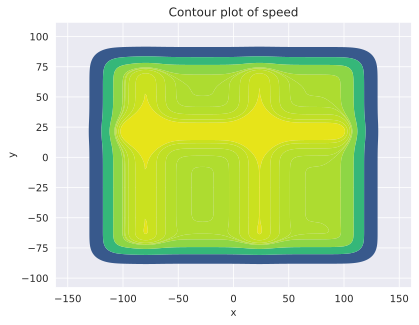

In [18]:
df = pd.DataFrame({'x': filtered["x"], 'y': filtered["y"], 'u': filtered["vx"]/10})
sns.kdeplot(data=df, x=df.x, y=df.y, cmap="viridis", fill=True)

# Set the plot title and labels
plt.title("Contour plot of speed")
plt.xlabel("x")
plt.ylabel("y")

# Show the plot
plt.show()

In [1]:
filtered.shape

NameError: name 'filtered' is not defined

In [ ]:
X, Y = np.meshgrid(filtered["x"], filtered["y"])

In [ ]:
U = filtered["vx"].reshape((len(filtered["y"]), len(filtered["x"])))

In [16]:
# Create the contour plot
plt.contourf(X, Y, U)
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

,epoch,dis_loss,gen_loss,dis_accuracy,dis_recall,dis_precision,gen_mse,time
0,1,2.7183,3.4495,0.4854,0.6498,0.6718,0.4870,"03/16/2023, 19:27:54"
1,2,1.4490,1.5053,0.4885,0.6516,0.6732,0.0664,"03/16/2023, 19:28:18"
2,3,1.4083,1.0099,0.4847,0.6469,0.6738,0.0214,"03/16/2023, 19:28:42"
3,4,1.3988,0.8414,0.4812,0.6487,0.6665,0.0126,"03/16/2023, 19:29:05"
4,5,1.3941,0.7651,0.4832,0.6606,0.6612,0.0083,"03/16/2023, 19:29:28"


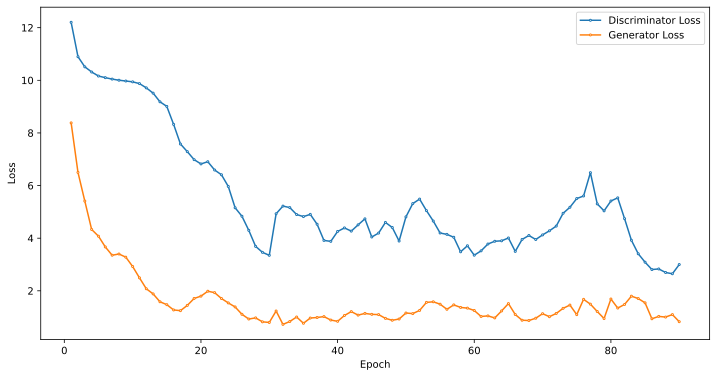

In [14]:
fig,ax = plt.subplots(1,figsize=(12,6))
e = 0
# ax.plot(df["epoch"],df["total_loss"],'o-',markerfacecolor='w',markersize=2)
ax.plot(df_cgan[df_cgan["epoch"]>=e]["epoch"],df_cgan[df_cgan["epoch"]>=e]["dis_loss"],'o-',markerfacecolor='w',markersize=2)
ax.plot(df_cgan[df_cgan["epoch"]>=e]["epoch"],df_cgan[df_cgan["epoch"]>=e]["gen_loss"],'o-',markerfacecolor='w',markersize=2)
ax.legend(["Discriminator Loss","Generator Loss"])
ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
plt.show()

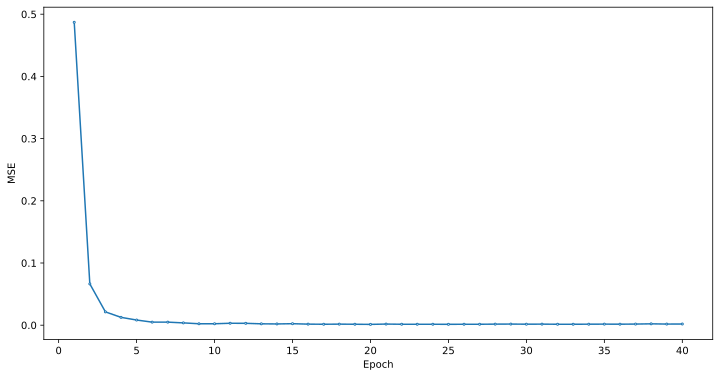

In [54]:
fig,ax = plt.subplots(1,figsize=(12,6))
e = 0
# ax.plot(df["epoch"],df["total_loss"],'o-',markerfacecolor='w',markersize=2)
ax.plot(df_cgan[df_cgan["epoch"]>=e]["epoch"],df_cgan[df_cgan["epoch"]>=e]["gen_mse"],'o-',markerfacecolor='w',markersize=2)
ax.set_ylabel('MSE')
ax.set_xlabel('Epoch')
plt.show()

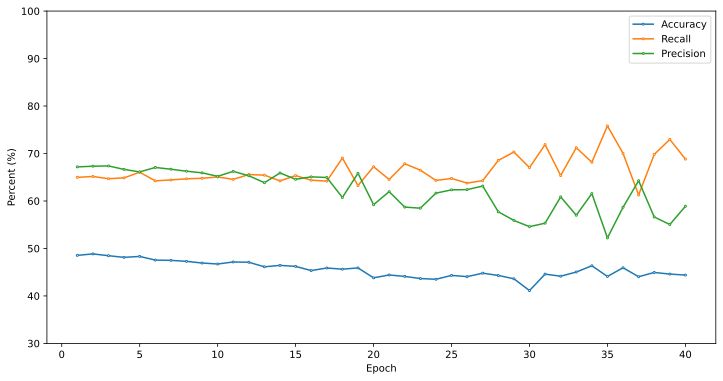

In [14]:
fig,ax = plt.subplots(1,figsize=(12,6))
e = 0
# ax.plot(df["epoch"],df["total_loss"],'o-',markerfacecolor='w',markersize=2)
ax.set_ylim([30, 100])
ax.plot(df_cgan[df_cgan["epoch"]>=e]["epoch"],(df_cgan[df_cgan["epoch"]>=e]["dis_accuracy"])*100,'o-',markerfacecolor='w',markersize=2)
ax.plot(df_cgan[df_cgan["epoch"]>=e]["epoch"],(df_cgan[df_cgan["epoch"]>=e]["dis_recall"])*100,'o-',markerfacecolor='w',markersize=2)
ax.plot(df_cgan[df_cgan["epoch"]>=e]["epoch"],(df_cgan[df_cgan["epoch"]>=e]["dis_precision"])*100,'o-',markerfacecolor='w',markersize=2)
ax.legend(["Accuracy","Recall","Precision"])
ax.set_ylabel('Percent (%)')
ax.set_xlabel('Epoch')
plt.show()

In [5]:
generated_samples = pd.read_csv(f"../logs/generated_result_1itter.csv", index_col=False)
real_data = pd.read_csv(f"../dataset/wind_forecast_2009.csv", index_col=False)
real_data.drop(columns=['date'], inplace=True)

In [6]:
generated_samples.shape, real_data.shape, real_data.columns

((123648, 7),
 (123648, 7),
 Index(['time_frame', 'hrs', 'u', 'v', 'ws', 'wd', 'farm'], dtype='object'))

In [37]:
real_data.describe()

,time_frame,hrs,u,v,ws,wd,farm
count,123648.000000,123648.000000,123648.000000,123648.000000,123648.000000,123648.000000,123648.000000
mean,184.500000,24.500000,1.123625,0.368114,4.362931,157.761595,4.000000
std,106.232487,13.853455,3.389912,3.360941,2.269398,104.355830,2.000008
min,1.000000,1.000000,-12.520000,-12.690000,0.020000,0.000000,1.000000
25%,92.750000,12.750000,-1.340000,-2.050000,2.770000,71.180000,2.000000
50%,184.500000,24.500000,1.290000,0.260000,3.890000,135.195000,4.000000
75%,276.250000,36.250000,3.280000,2.640000,5.570000,247.092500,6.000000
max,368.000000,48.000000,16.150000,15.010000,16.560000,360.000000,7.000000


In [38]:
generated_samples.describe()

,time_frame,hrs,farm,u,v,ws,wd
count,123648.000000,123648.000000,123648.000000,123648.000000,123648.000000,123648.000000,123648.000000
mean,184.500000,24.500000,4.000000,0.945162,-0.722813,-1.016319,109.700280
std,106.232487,13.853455,2.000008,0.751670,1.564961,7.793977,58.064612
min,1.000000,1.000000,1.000000,-3.761079,-10.521458,-49.817196,-253.870100
25%,92.750000,12.750000,2.000000,0.577081,-1.489028,-4.831310,81.271774
50%,184.500000,24.500000,4.000000,1.137953,-0.321524,0.983174,124.595565
75%,276.250000,36.250000,6.000000,1.555316,0.547698,5.311314,156.841667
max,368.000000,48.000000,7.000000,1.763751,0.981249,7.470536,172.924710


In [ ]:

# Assuming you have two datasets x and y
plt.hist(real_data['wd'], bins=10, alpha=0.5, label='Real Dataset')
plt.hist(generated_samples['wd'], bins=10, alpha=0.5, label='Generated Dataset')
plt.legend(loc='upper right')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have two datasets x and y
sns.kdeplot(real_data['wd'], fill=True, label='Real Dataset')
sns.kdeplot(generated_samples['wd'], fill=True, label='Generated Dataset')
plt.legend(loc='upper right')
plt.title("wd")
plt.show()

In [ ]:
data = [real_data['wd'], generated_samples['wd']]
plt.boxplot(data, labels=['Real Dataset', 'Generated Dataset'])
plt.show()

In [ ]:
sns.violinplot(data=[real_data['wd'], generated_samples['wd']], inner='stick', palette='pastel')
plt.show()

In [ ]:
# ECDF (Empirical Cumulative Distribution Function) Plots
import statsmodels.api as sm

ecdf_x = sm.distributions.ECDF(real_data['wd'])
ecdf_y = sm.distributions.ECDF(generated_samples['wd'])
plt.step(ecdf_x.x, ecdf_x.y, label='Real Dataset')
plt.step(ecdf_y.x, ecdf_y.y, label='Generated Dataset')
plt.legend(loc='upper left')
plt.show()

In [ ]:
# QQ (Quantile-Quantile) Plots: compare the quantiles of the two datasets
sm.qqplot(real_data['wd'], line='s')
plt.title('Real Dataset')
plt.show()

sm.qqplot(generated_samples['wd'], line='s')
plt.title('Generated Dataset')
plt.show()

### Merging to datasets

In [53]:
merged = pd.merge(real_data, generated_samples, on=["time_frame", "hrs", "farm"])

In [54]:
merged.head()

,time_frame,hrs,u_x,v_x,ws_x,wd_x,farm,u_y,v_y,ws_y,wd_y
0,1,1,2.34,-0.79,2.47,108.68,1,1.753117,0.959116,7.360296,172.10345
1,1,2,2.18,-0.99,2.40,114.31,1,1.753645,0.960214,7.365772,172.14430
2,1,3,2.20,-1.21,2.51,118.71,1,1.757210,0.967602,7.402608,172.41847
3,1,4,2.35,-1.40,2.73,120.86,1,1.741864,0.935620,7.243398,171.23228
4,1,5,2.53,-1.47,2.93,120.13,1,1.734995,0.921387,7.172367,170.70337


In [59]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [60]:
mse_u = mean_absolute_error(merged['u_x'], merged['u_y'])
mse_v = mean_absolute_error(merged['v_x'], merged['v_y'])
mse_ws = mean_absolute_error(merged['ws_x'], merged['ws_y'])
mse_wd = mean_absolute_error(merged['wd_x'], merged['wd_y'])

In [62]:
mse_u, mse_v,  mse_ws, mse_wd

(2.72360419641032, 3.0817852296986055, 6.969605726685532, 104.22700770405072)